# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API 
**Objective:** <br>
Build a reusable and production-ready machine learning pipeline for predicting customer churn.<br>
**Dataset:** <br>
- Telco Churn Dataset<br>
  
**Instructions:** <br>
● Implement data preprocessing steps (e.g., scaling, encoding) using Pipeline<br>
● Train models like Logistic Regression and Random Forest<br>
● Use GridSearchCV for hyperparameter tuning<br>
● Export the complete pipeline using joblib<br>
**Skills Gained:** <br>
● ML pipeline construction<br>
● Hyperparameter tuning with GridSearch<br>
● Model export and reusability<br>
● Production-readiness practices

#  Load Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("dataset/Telco_Cusomer_Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Analysis Data

In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


TotalCharges columns has a object data type so we convert it into float data type

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


# Check missing values

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Column TotalCharges has 11 NULL values so for cleaning of data we delete these rows.

In [11]:
df.dropna(subset=["TotalCharges"] , inplace=True)

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Cecking the target column

In [13]:
print(df['Churn'].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [14]:
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [15]:
# plot it 
import matplotlib.pyplot as plt

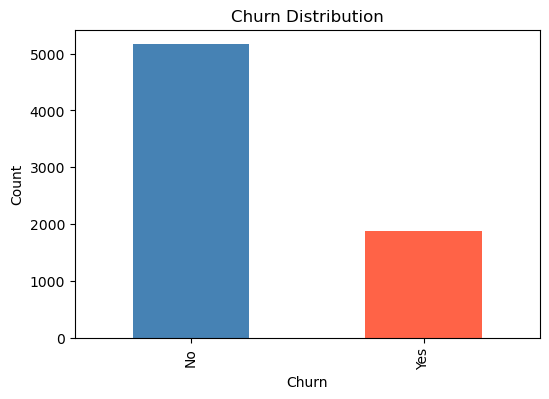

In [16]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Numerical Features Analysis

In [17]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

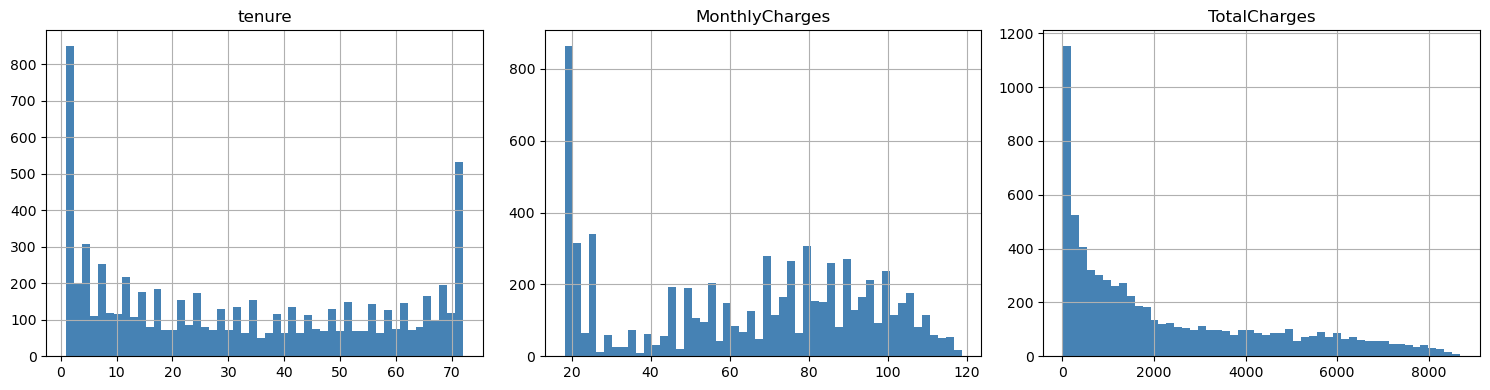

In [18]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    df[col].hist(ax=axes[i], bins=50, color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


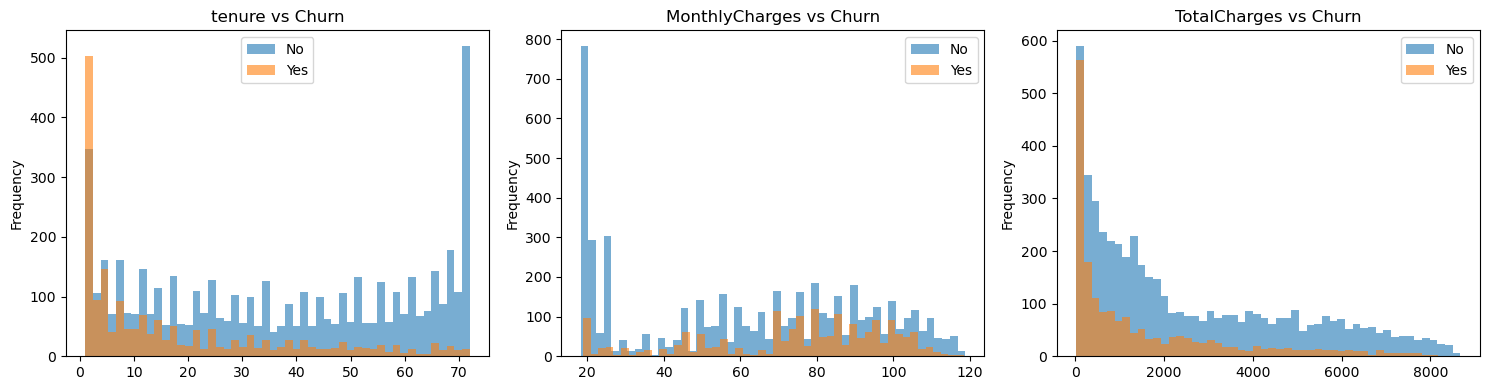

In [19]:
# Relation with targets 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    df.groupby('Churn')[col].plot(kind='hist', ax=axes[i],alpha=0.6, legend=True, bins=50)
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

# Categorical Features Analysis

In [20]:
# Important categorical columns
cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity" ,"PaperlessBilling"] 


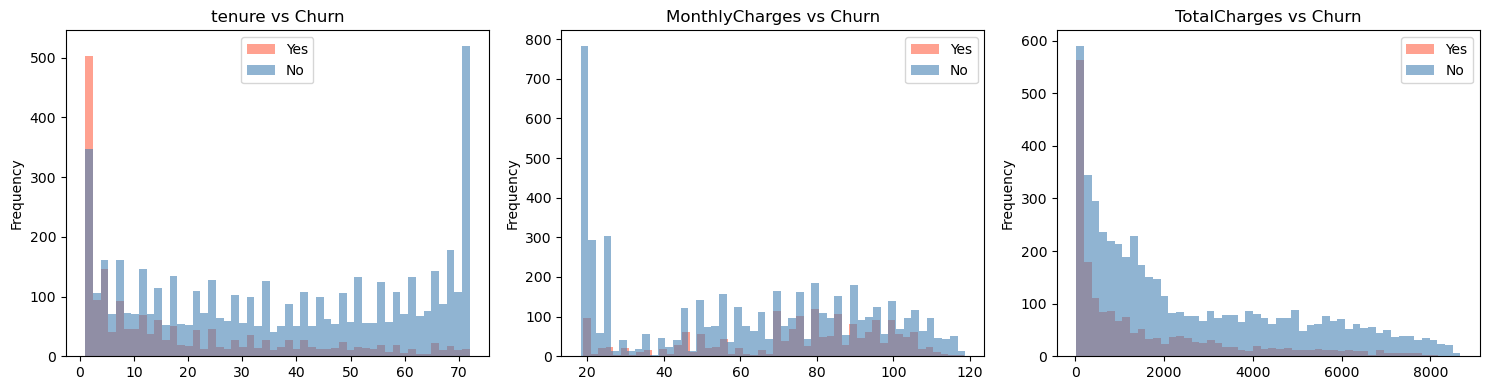

In [21]:
# Numerical columns vs Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    # Churn Yes
    df[df['Churn']=='Yes'][col].plot(kind='hist', ax=axes[i], alpha=0.6, label='Yes', bins=50, color='tomato')
    # Churn No
    df[df['Churn']=='No'][col].plot(kind='hist', ax=axes[i], alpha=0.6, label='No', bins=50, color='steelblue')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].legend()

plt.tight_layout()
plt.show()


# Select important feactures 

In [22]:
important_features = [
    "tenure",
    "MonthlyCharges", 
    "TotalCharges",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "SeniorCitizen"
]

print("Selected Features:", important_features)

Selected Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'SeniorCitizen']


# Chose feactures and targets

In [23]:
X = df[important_features]

In [24]:
print("X shape:", X.shape)

X shape: (7032, 10)


In [25]:
y = df["Churn"].map({"Yes" : 1 , "No" : 0})

In [26]:
print(y.head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [27]:
print("Y shape:", y.shape)

Y shape: (7032,)


In [28]:
print("\nClass Distribution:")
print(y.value_counts())


Class Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


# Seprate numaric and catogery columns 

In [29]:
numerical_cols 

['tenure', 'MonthlyCharges', 'TotalCharges']

In [30]:
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService','OnlineSecurity', 'TechSupport', 'PaperlessBilling','SeniorCitizen']

In [31]:
categorical_cols

['Contract',
 'PaymentMethod',
 'InternetService',
 'OnlineSecurity',
 'TechSupport',
 'PaperlessBilling',
 'SeniorCitizen']

# Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=40 , stratify=y
)

In [34]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 10)
Test size: (1407, 10)


# Preprocessor

In [35]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer

In [36]:
preprocessor = ColumnTransformer( 
    transformers=[ 
        ('num', StandardScaler(), numerical_cols), 
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols) 
    ] 
)

# Train random forest model 

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf_pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [39]:
parameters = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__random_state": [42]
}

In [40]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid = parameters,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [41]:
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [53]:
best_rf = grid_rf.best_estimator_
print(best_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Contract', 'PaymentMethod',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'TechSupport',
                                                   'PaperlessBilling',
                                                   'SeniorCitizen'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balan

In [54]:
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100, 'classifier__random_state': 42}


In [55]:
print("Best CV Score:", grid_rf.best_score_)

Best CV Score: 0.6342016587977597


In [56]:
print("Best CV Score:", grid_rf.best_score_)

Best CV Score: 0.6342016587977597


#### Predict train and test data

In [57]:
y_train_pred = best_rf.predict(X_train)

In [58]:
y_test_pred = best_rf.predict(X_test)

In [59]:
# Check accuracy
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [60]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

Train Accuracy: 0.8241777777777778


In [61]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Test Accuracy: 0.7690120824449183


### The model shows no significant signs of overfitting. The gap between training accuracy (82.4%) and test accuracy (76.9%) is moderate, suggesting that the model maintains good generalization performance on unseen data.

# Confusion Matrix

In [62]:
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

Confusion Matrix (Test):
[[801 232]
 [ 93 281]]


In [63]:
print("Confusion Matrix (Train):")
confusion_matrix(y_train, y_train_pred)

Confusion Matrix (Train):


array([[3365,  765],
       [ 224, 1271]])

# Classification Report

In [64]:
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1033
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



# Train Logist Regression Model

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
lr_pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("classifier", LogisticRegression())
])

In [67]:
# Parameters

param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_iter': [100, 200]
} 

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

In [70]:
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'classifier__C': [0.001, 0.01, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__max_iter': [100, 200], 'classifier__penalty': ['l1', 'l2'], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [71]:
best_lr = grid_lr.best_estimator_
print(best_lr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Contract', 'PaymentMethod',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'TechSupport',
                                                   'PaperlessBilling',
                                                   'SeniorCitizen'])])),
                ('classifier',
                 LogisticRegression(C=1, class_weight='bala

In [81]:
print("Best Params:", grid_lr.best_params_)

Best Params: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


In [82]:
print("Best F1 Score:", grid_lr.best_score_)

Best F1 Score: 0.6192835752958838


# Evaluation

In [83]:
y_train_pred = best_lr.predict(X_train)

In [84]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

Train Accuracy: 0.7409777777777777


In [85]:
y_test_pred = best_lr.predict(X_test)

In [86]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Test Accuracy: 0.7533759772565742


### The Logistic Regression model demonstrates stable performance, achieving a training accuracy of 74.1% and a test accuracy of 75.3%. The close alignment between these values suggests good generalization and indicates that the model is neither overfitting nor underfitting.

### Confusion Matrix

In [87]:
print(confusion_matrix(y_test, y_test_pred))

[[755 278]
 [ 69 305]]


In [88]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1033
           1       0.52      0.82      0.64       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.75      0.77      1407



# Export the complete pipeline using joblib

In [89]:
import joblib

In [90]:
best_model_pipeline = grid_lr.best_estimator_

In [91]:
joblib.dump(best_model_pipeline, 'telco_churn_pipeline.joblib')

print("Pipeline exported successfully!")

Pipeline exported successfully!


## Final Decision

The most suitable model to save is **Logistic Regression**.

The reason is straightforward. In a churn prediction problem, missing a customer who is likely to churn (false negative) is more critical than overall accuracy. Logistic Regression achieves a higher **recall (0.82)** and slightly better **F1-score (0.64)** compared to Random Forest.

Although Random Forest provides higher accuracy, it fails to correctly identify a significant number of churned customers, which can lead to business loss.

Therefore, Logistic Regression is the better choice.

```python
joblib.dump(best_lr, 'telco_churn_pipeline.joblib')
```



 

## Project Report: Customer Churn Prediction

### Objective

The objective of this project is to develop a production-ready machine learning pipeline to predict customer churn using the Telco Customer Churn dataset. The goal is to identify customers who are likely to leave the service, allowing businesses to take proactive retention measures.

 
### Data Preprocessing

The dataset was cleaned and prepared before model training.

* The `TotalCharges` column was converted from object to numeric format
* Missing values were removed
* Important features were selected to improve efficiency and reduce complexity
 

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the data.

* The dataset is imbalanced, with approximately 26% churned customers
* Numerical features such as `tenure`, `MonthlyCharges`, and `TotalCharges` were analyzed
* Key observations:

  * Customers with lower tenure are more likely to churn
  * Customers with higher monthly charges show higher churn rates
 

### Feature Selection

The following features were selected:

**Numerical Features:**

* tenure
* MonthlyCharges
* TotalCharges

**Categorical Features:**

* Contract
* PaymentMethod
* InternetService
* OnlineSecurity
* TechSupport
* PaperlessBilling

**Additional Feature:**

* SeniorCitizen
 

### Machine Learning Pipeline

A machine learning pipeline was built using Scikit-learn’s Pipeline API to ensure a reusable and consistent workflow.

* `ColumnTransformer` was used for preprocessing:

  * StandardScaler for numerical features
  * OneHotEncoder for categorical features

This ensures that preprocessing and model training are applied consistently during both training and prediction.
 

### Model Training

Two models were trained:

* Random Forest Classifier
* Logistic Regression

 

### Hyperparameter Tuning

GridSearchCV was used for hyperparameter tuning:

* Logistic Regression was optimized using **F1-score**
* Random Forest was also optimized using **F1-score**

 

### Model Evaluation

#### Random Forest

* Accuracy: 0.77
* Recall (Churn): 0.75
* F1-score: 0.63

#### Logistic Regression

* Accuracy: 0.75
* Recall (Churn): 0.82
* F1-score: 0.64

 

### Final Model Selection

Logistic Regression was selected as the final model.

Reasons:

* Higher recall for churned customers
* Better F1-score
* More suitable for imbalanced datasets
* Aligns better with the business objective of identifying customers at risk

 

### Model Deployment

The final pipeline was exported using joblib:

```python
joblib.dump(best_lr, 'telco_churn_pipeline.joblib')
```

This allows the model to be reused in a production environment without repeating preprocessing steps.

 

### Conclusion

This project successfully demonstrates the development of an end-to-end machine learning pipeline for customer churn prediction.

The use of pipelines, proper preprocessing, and hyperparameter tuning makes the solution scalable, reusable, and production-ready. Logistic Regression performed best for churn prediction and was therefore selected as the final model for deployment.
 